<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista-5-altMIchal/blob/main/ml_lab05_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Zadanie 2**

# **1. Analiza Eksploracyjna (EDA)**

**Importy**

In [ ]:
import pandas as pd
import numpy as np
import time

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv('agaricus-lepiota.data', header=None)
column_names = [
    "poisonous", "cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-root", "stalk-surface-above-ring",
    "stalk-surface-below-ring", "stalk-color-above-ring",
    "stalk-color-below-ring", "veil-type", "veil-color", "ring-number",
    "ring-type", "spore-print-color", "population", "habitat"
]

df.columns = column_names

df.head()

,poisonous,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Interesuje nas głównie kolumna targetowa - poisonous

Text(0.5, 1.0, 'Rozkład wartości targetowej (poisonous)')

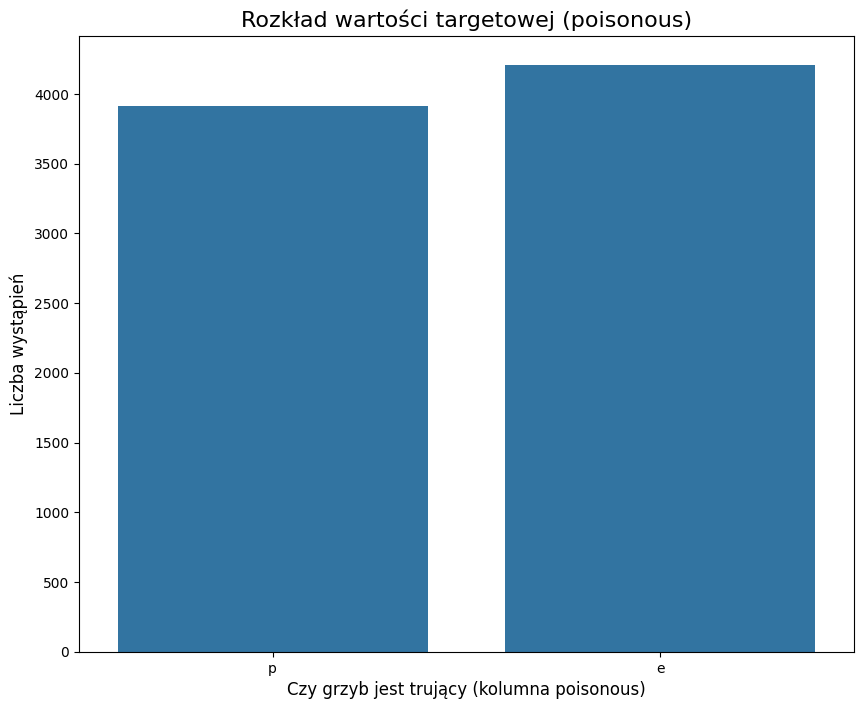

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(data=df, x='poisonous')
plt.xlabel('Czy grzyb jest trujący (kolumna poisonous)', fontsize=12)
plt.ylabel('Liczba wystąpień', fontsize=12)
plt.title('Rozkład wartości targetowej (poisonous)', fontsize=16)

Widzimy, że nasza kolumna docelowa jest całkiem zbilansowana

In [ ]:
print(30*"-", "Opis kolumn", 30*"-")
df.info()
print("\n")

stalk_root_missing_values = (df["stalk-root"] == "?").sum()
print("Brakujące wartości w stalk-root:", stalk_root_missing_values)

------------------------------ Opis kolumn ------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   poisonous                 8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stal

Mamy 2480 brakujących wartości w kolumnie stalk-root.

**Macierz Korelacji**

In [ ]:
# Tworzymy macierz korelacji żeby zbadać z czym koreluje kolumna stalk-root

df_encoded = df.copy()

df_encoded = df_encoded.fillna("missing")

for col in df_encoded.columns:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

corr_matrix = df_encoded.corr(method='spearman')

stalk_root_corr = corr_matrix['stalk-root'].sort_values(ascending=False)

print("--- TOP KORELACJI DLA KOLUMNY STALK-ROOT ---")
print(stalk_root_corr)
print("\n--------------------------------------------\n")

--- TOP KORELACJI DLA KOLUMNY STALK-ROOT ---
stalk-root                  1.000000
gill-color                  0.417302
ring-type                   0.344702
bruises                     0.344420
cap-color                   0.320258
gill-spacing                0.279367
stalk-color-above-ring      0.206267
veil-color                  0.203772
stalk-color-below-ring      0.203300
gill-attachment             0.176543
stalk-surface-below-ring    0.135398
stalk-surface-above-ring    0.067651
cap-shape                   0.008079
habitat                    -0.038005
cap-surface                -0.138296
population                 -0.180806
stalk-shape                -0.191921
odor                       -0.265026
ring-number                -0.292361
poisonous                  -0.388104
gill-size                  -0.464623
spore-print-color          -0.540546
veil-type                        NaN
Name: stalk-root, dtype: float64

--------------------------------------------



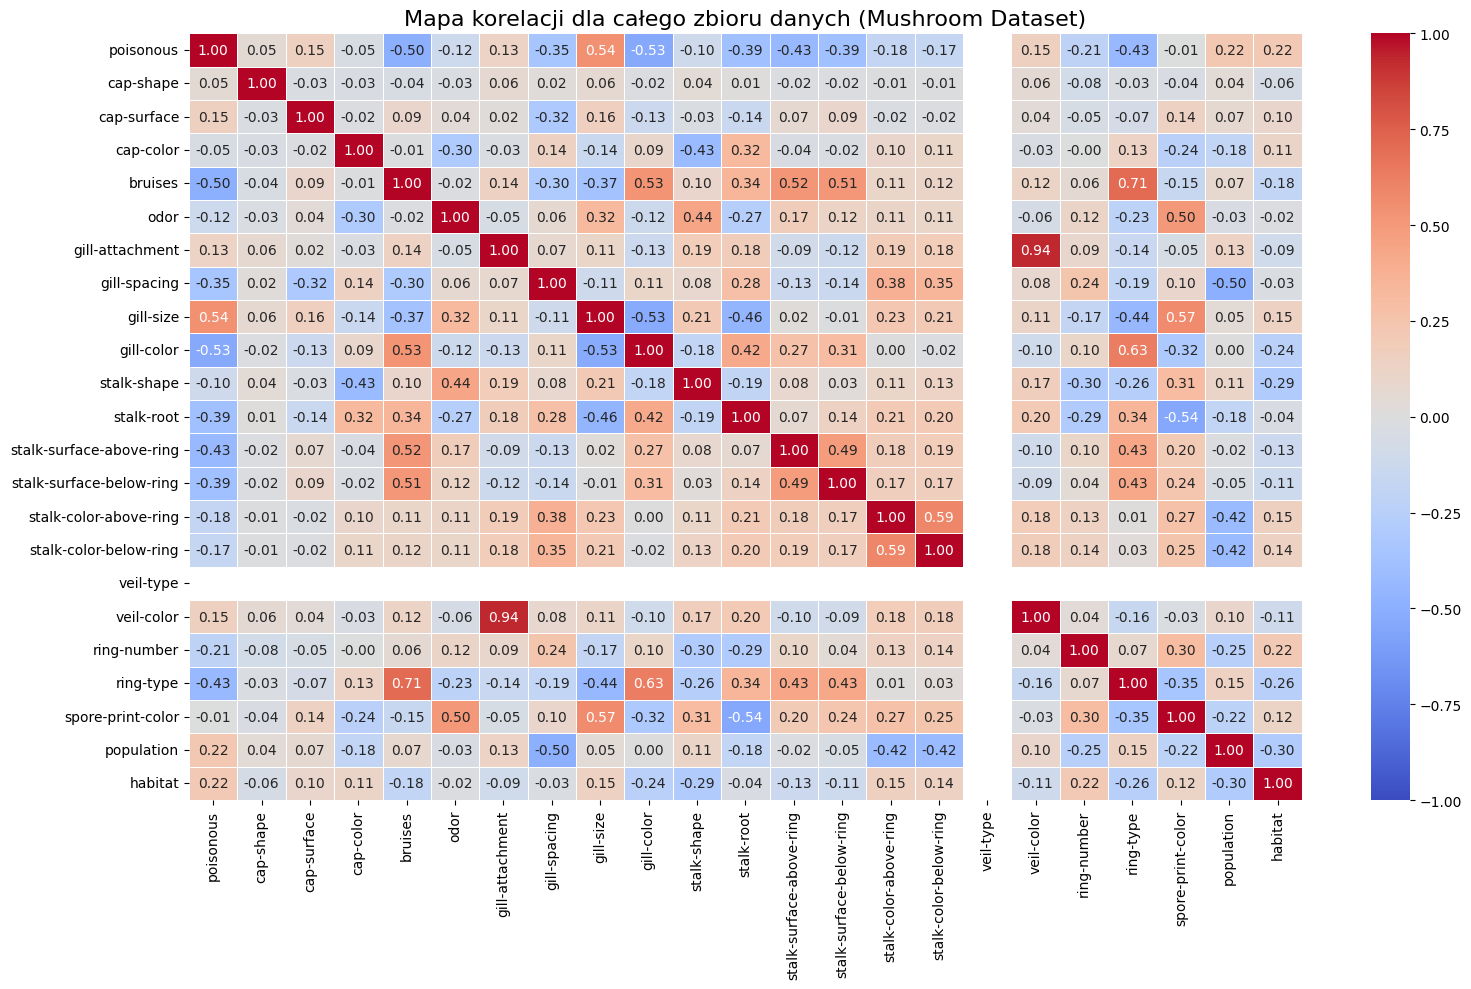

In [ ]:
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Mapa korelacji dla całego zbioru danych (Mushroom Dataset)', fontsize=16)
plt.tight_layout()

plt.savefig('mapa_korelacji.png')
plt.show()

**Podział danych na zbiory**

In [ ]:
X = df.drop('poisonous', axis=1)
y = df['poisonous'].map({'e': 0, 'p': 1})
X['stalk-root'] = X['stalk-root'].replace("?", np.nan)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Okazuje się, że "stalk-root" najmocniej koreluje z kolumną "gill-color". Teraz uzupełnimy brakujące wartości poprzez modę cechy "stalk-root" dla tej kolumny. Zrobimy to jednak tylko na zbiorze treningowym żeby uniknąć wycieku danych.

In [ ]:
modes_from_train = X_train.groupby("gill-color")["stalk-root"].agg(
    lambda x: x.mode()[0] if not x.mode().empty else "b"
).to_dict()

def fill_missing(row):
    if pd.isna(row['stalk-root']):
        return modes_from_train.get(row['gill-color'], 'b')
    return row['stalk-root']

X_train['stalk-root'] = X_train.apply(fill_missing, axis=1)
X_test['stalk-root'] = X_test.apply(fill_missing, axis=1)

**One-Hot Encoding**

In [ ]:
X_combined = pd.concat([X_train, X_test])
X_combined = pd.get_dummies(X_combined, drop_first=True, dtype=int)

X_train = X_combined.iloc[:len(X_train)]
X_test = X_combined.iloc[len(X_train):]

**Skalowanie Danych**

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **2. Wybór i trenowanie modeli**

**Funkcja Walidująca**

In [ ]:
def validate_model(model, X_train, y_train, X_test, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_pred

    accuracy = accuracy_score(y_test, y_pred)
    classification_rep = classification_report(y_test, y_pred)

    print(f"\n" + "="*50)
    print(f" WYNIKI DLA: {model.__class__.__name__}")
    print("="*50)
    print(f"Czas treningu:   {training_time:.4f} sekund")
    print(f"Czas predykcji:  {prediction_time:.4f} sekund")
    print(f"Dokładność:      {accuracy:.4f}\n")
    print("Raport klasyfikacji:")
    print(classification_rep)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Jadalne (0)', 'Trujące (1)'],
                yticklabels=['Jadalne (0)', 'Trujące (1)'],
                linewidths=0.5, linecolor='black')

    plt.xlabel('Przewidywana klasa przez model', fontsize=12)
    plt.ylabel('Rzeczywista klasa (Prawda)', fontsize=12)
    plt.title(f'Macierz Pomyłek - {model.__class__.__name__}', fontsize=15, pad=15)
    plt.show()

    return model.__class__.__name__, accuracy, training_time, prediction_time


**Drzewo Decyzyjne**

In [ ]:
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)

y_pred = base_tree.predict(X_test)

**Regresja Logistyczna**

In [ ]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log_reg = log_reg.predict(X_test)

**Bagging**

In [ ]:
# funkcja szukająca najlepszych hiperparametrów w baggingu, zwraca objekt
# grid_search z najlepszymi parametrami
def evaluate_hiperparameters_bagging(model, X_train, y_train, X_test, y_test):
    param_grid = {
        'n_estimators': [1, 5, 10, 15, 20, 30, 50],
        'bootstrap': [True, False],
        'bootstrap_features': [True, False]
    }

    bagging = BaggingClassifier(estimator=model, random_state=42)

    grid_search = GridSearchCV(
        estimator=bagging,
        param_grid=param_grid,
        scoring='accuracy',
        cv=5,
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train)

    test_score = grid_search.score(X_test, y_test)

    model_name = model.__class__.__name__

    return grid_search

In [ ]:
models = [
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42)),
    ('tree_unlimited', DecisionTreeClassifier(random_state=42)),
    ('tree_depth_3', DecisionTreeClassifier(random_state=42, max_depth=3))
]

trained_models = {}

for name, model_obj in models:
    best_grid = evaluate_hiperparameters_bagging(model_obj, X_train, y_train, X_test, y_test)

    trained_models[name] = best_grid

# **3. Walidacja wyuczonych modeli**

W przypadku naszego zadania, najważniejsze jest to żeby **unikać wyników FN** **(False Negative)**. Odzwierciedla ona w tym zbiorze ocenienie grzyba trującego jako zdrowy.

Powinniśmy poświęcić również czas na ocenienie czasu treningu i predykcji danego modelu. Nasza bateria jest na wyczerpaniu i chcemy żeby nasz model był jak najszybszy.

Powinniśmy zwrócić uwagę na metryce Recall ponieważ dobrze pokazuje ona przypadki FN.

Należy natomiast uważać na Accuracy, w naszym przypadku jest ona bardzo złudna bo nawet 1 jedzony trujący grzyb to poważne zatrucie.

In [ ]:
results = []


 WYNIKI DLA: DecisionTreeClassifier
Czas treningu:   0.0214 sekund
Czas predykcji:  0.0010 sekund
Dokładność:      1.0000

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



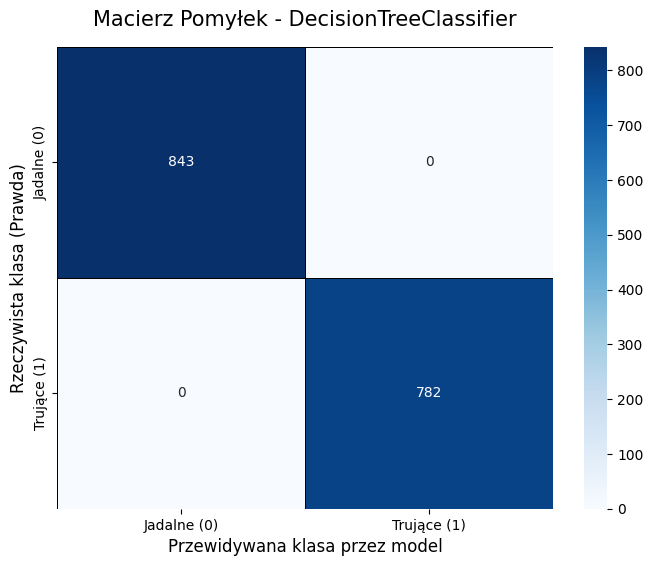

In [ ]:
results.append(validate_model(base_tree, X_train, y_train, X_test, y_test))


 WYNIKI DLA: LogisticRegression
Czas treningu:   0.0544 sekund
Czas predykcji:  0.0007 sekund
Dokładność:      1.0000

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



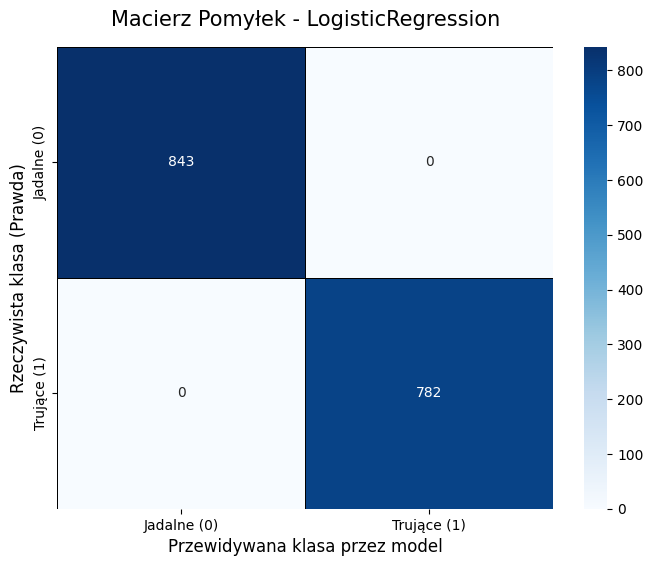

In [ ]:
results.append(validate_model(log_reg, X_train, y_train, X_test, y_test))


 WYNIKI DLA: BaggingClassifier
Czas treningu:   1.3379 sekund
Czas predykcji:  0.0103 sekund
Dokładność:      1.0000

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



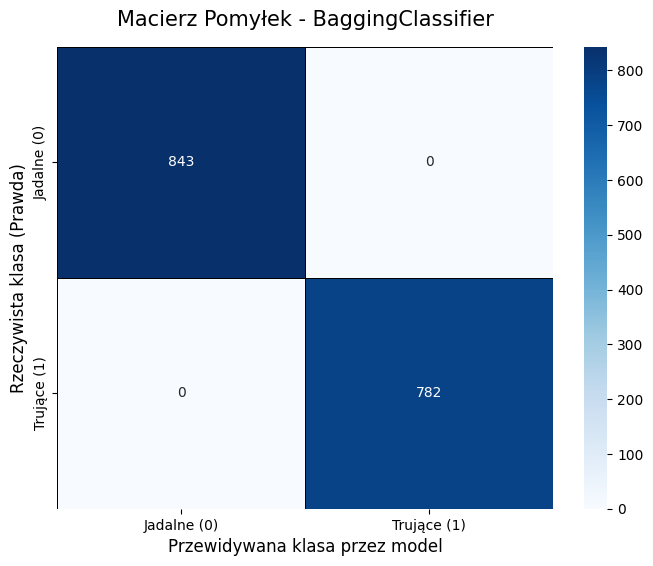

In [ ]:
results.append(validate_model(trained_models['log_reg'].best_estimator_, X_train, y_train, X_test, y_test))


 WYNIKI DLA: BaggingClassifier
Czas treningu:   0.0939 sekund
Czas predykcji:  0.0060 sekund
Dokładność:      1.0000

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       843
           1       1.00      1.00      1.00       782

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



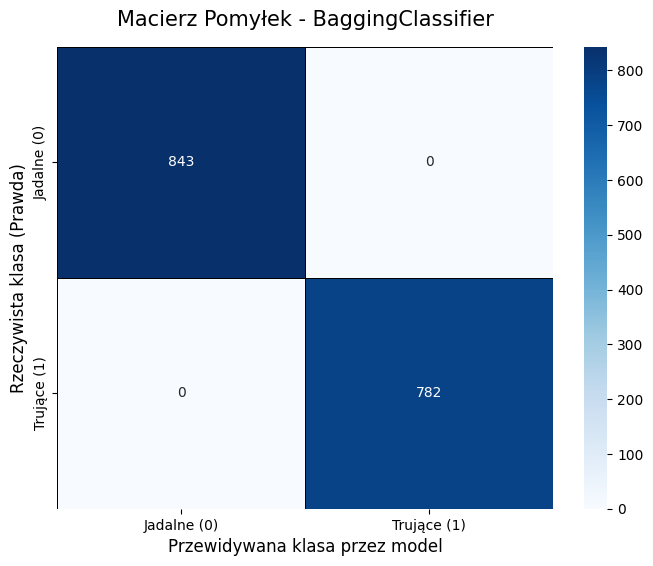

In [ ]:
results.append(validate_model(trained_models['tree_unlimited'].best_estimator_, X_train, y_train, X_test, y_test))


 WYNIKI DLA: BaggingClassifier
Czas treningu:   0.1534 sekund
Czas predykcji:  0.0064 sekund
Dokładność:      0.9828

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       843
           1       0.97      1.00      0.98       782

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



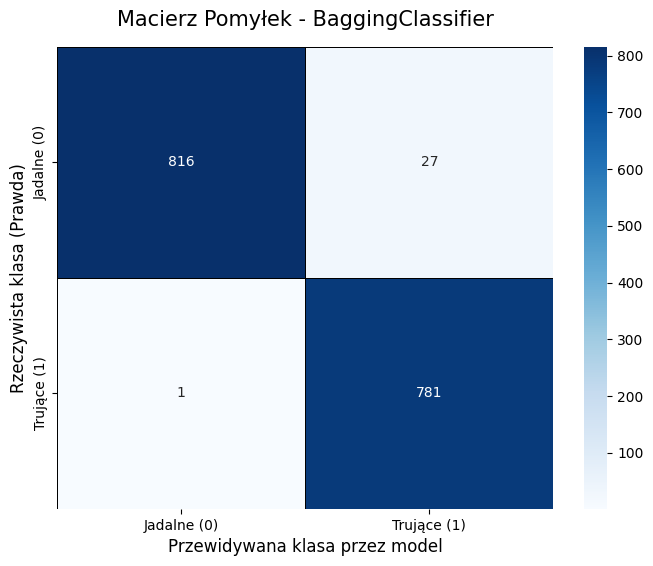

In [ ]:
results.append(validate_model(trained_models['tree_depth_3'].best_estimator_, X_train, y_train, X_test, y_test))

**Tabela zbiorcza modeli**

In [ ]:
summary_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Czas Treningu (s)', 'Czas Predykcji (s)'])

summary_df = summary_df.sort_values(by=['Accuracy', 'Czas Predykcji (s)'], ascending=[False, True]).reset_index(drop=True)

print("\n=== KOŃCOWY RANKING MODELI ===")
display(summary_df)


=== KOŃCOWY RANKING MODELI ===


,Model,Accuracy,Czas Treningu (s),Czas Predykcji (s)
0,LogisticRegression,1.000000,0.054421,0.000736
1,DecisionTreeClassifier,1.000000,0.021362,0.000954
2,BaggingClassifier,1.000000,0.093871,0.006038
3,BaggingClassifier,1.000000,1.337891,0.010294
4,BaggingClassifier,0.982769,0.153397,0.006446


**Tabela Ważności Cech**

In [ ]:
feature_importances = pd.DataFrame({
    'Cecha': X_combined.columns,
    'Ważność': base_tree.feature_importances_
})

feature_importances = feature_importances[feature_importances['Ważność'] > 0]
feature_importances = feature_importances.sort_values(by='Ważność', ascending=False).reset_index(drop=True)

print("\n=== NAJWAŻNIEJSZE CECHY WEDŁUG DRZEWA DECYZYJNEGO ===")
display(feature_importances)


=== NAJWAŻNIEJSZE CECHY WEDŁUG DRZEWA DECYZYJNEGO ===


,Cecha,Ważność
0,odor_n,0.623110
1,stalk-root_c,0.179952
2,stalk-surface-below-ring_y,0.111393
3,spore-print-color_r,0.034084
4,spore-print-color_u,0.020247
5,odor_l,0.010294
6,odor_c,0.009034
7,stalk-color-above-ring_n,0.005589
8,gill-spacing_w,0.001992
9,cap-surface_g,0.001841


/tmp/ipykernel_7839/1463307358.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importances, x='Ważność', y='Cecha', palette='viridis')


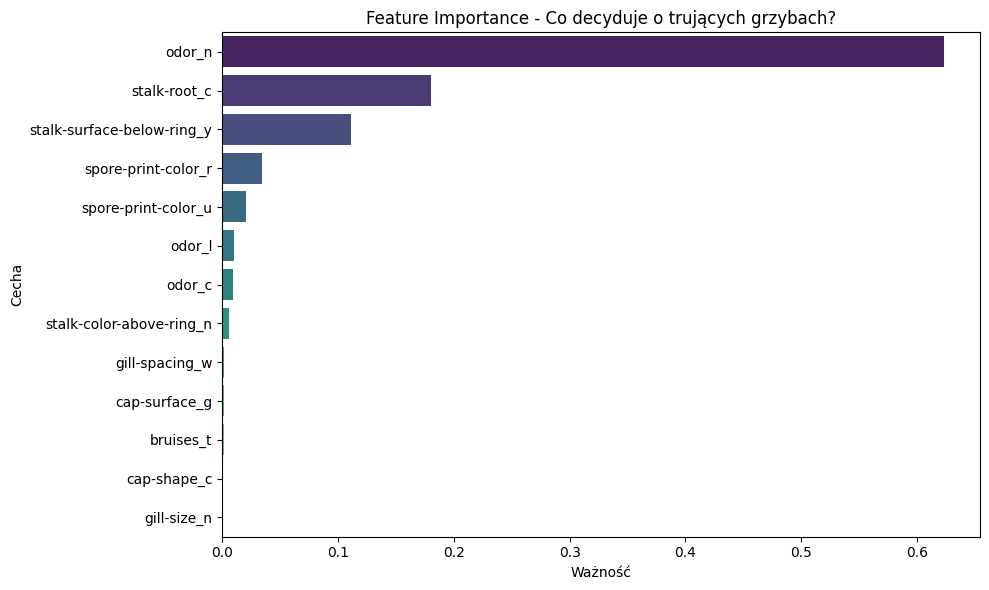

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances, x='Ważność', y='Cecha', palette='viridis')
plt.title('Feature Importance - Co decyduje o trujących grzybach?')
plt.tight_layout()
plt.show()

**Wizualizacja Drzewa Decyzyjnego**

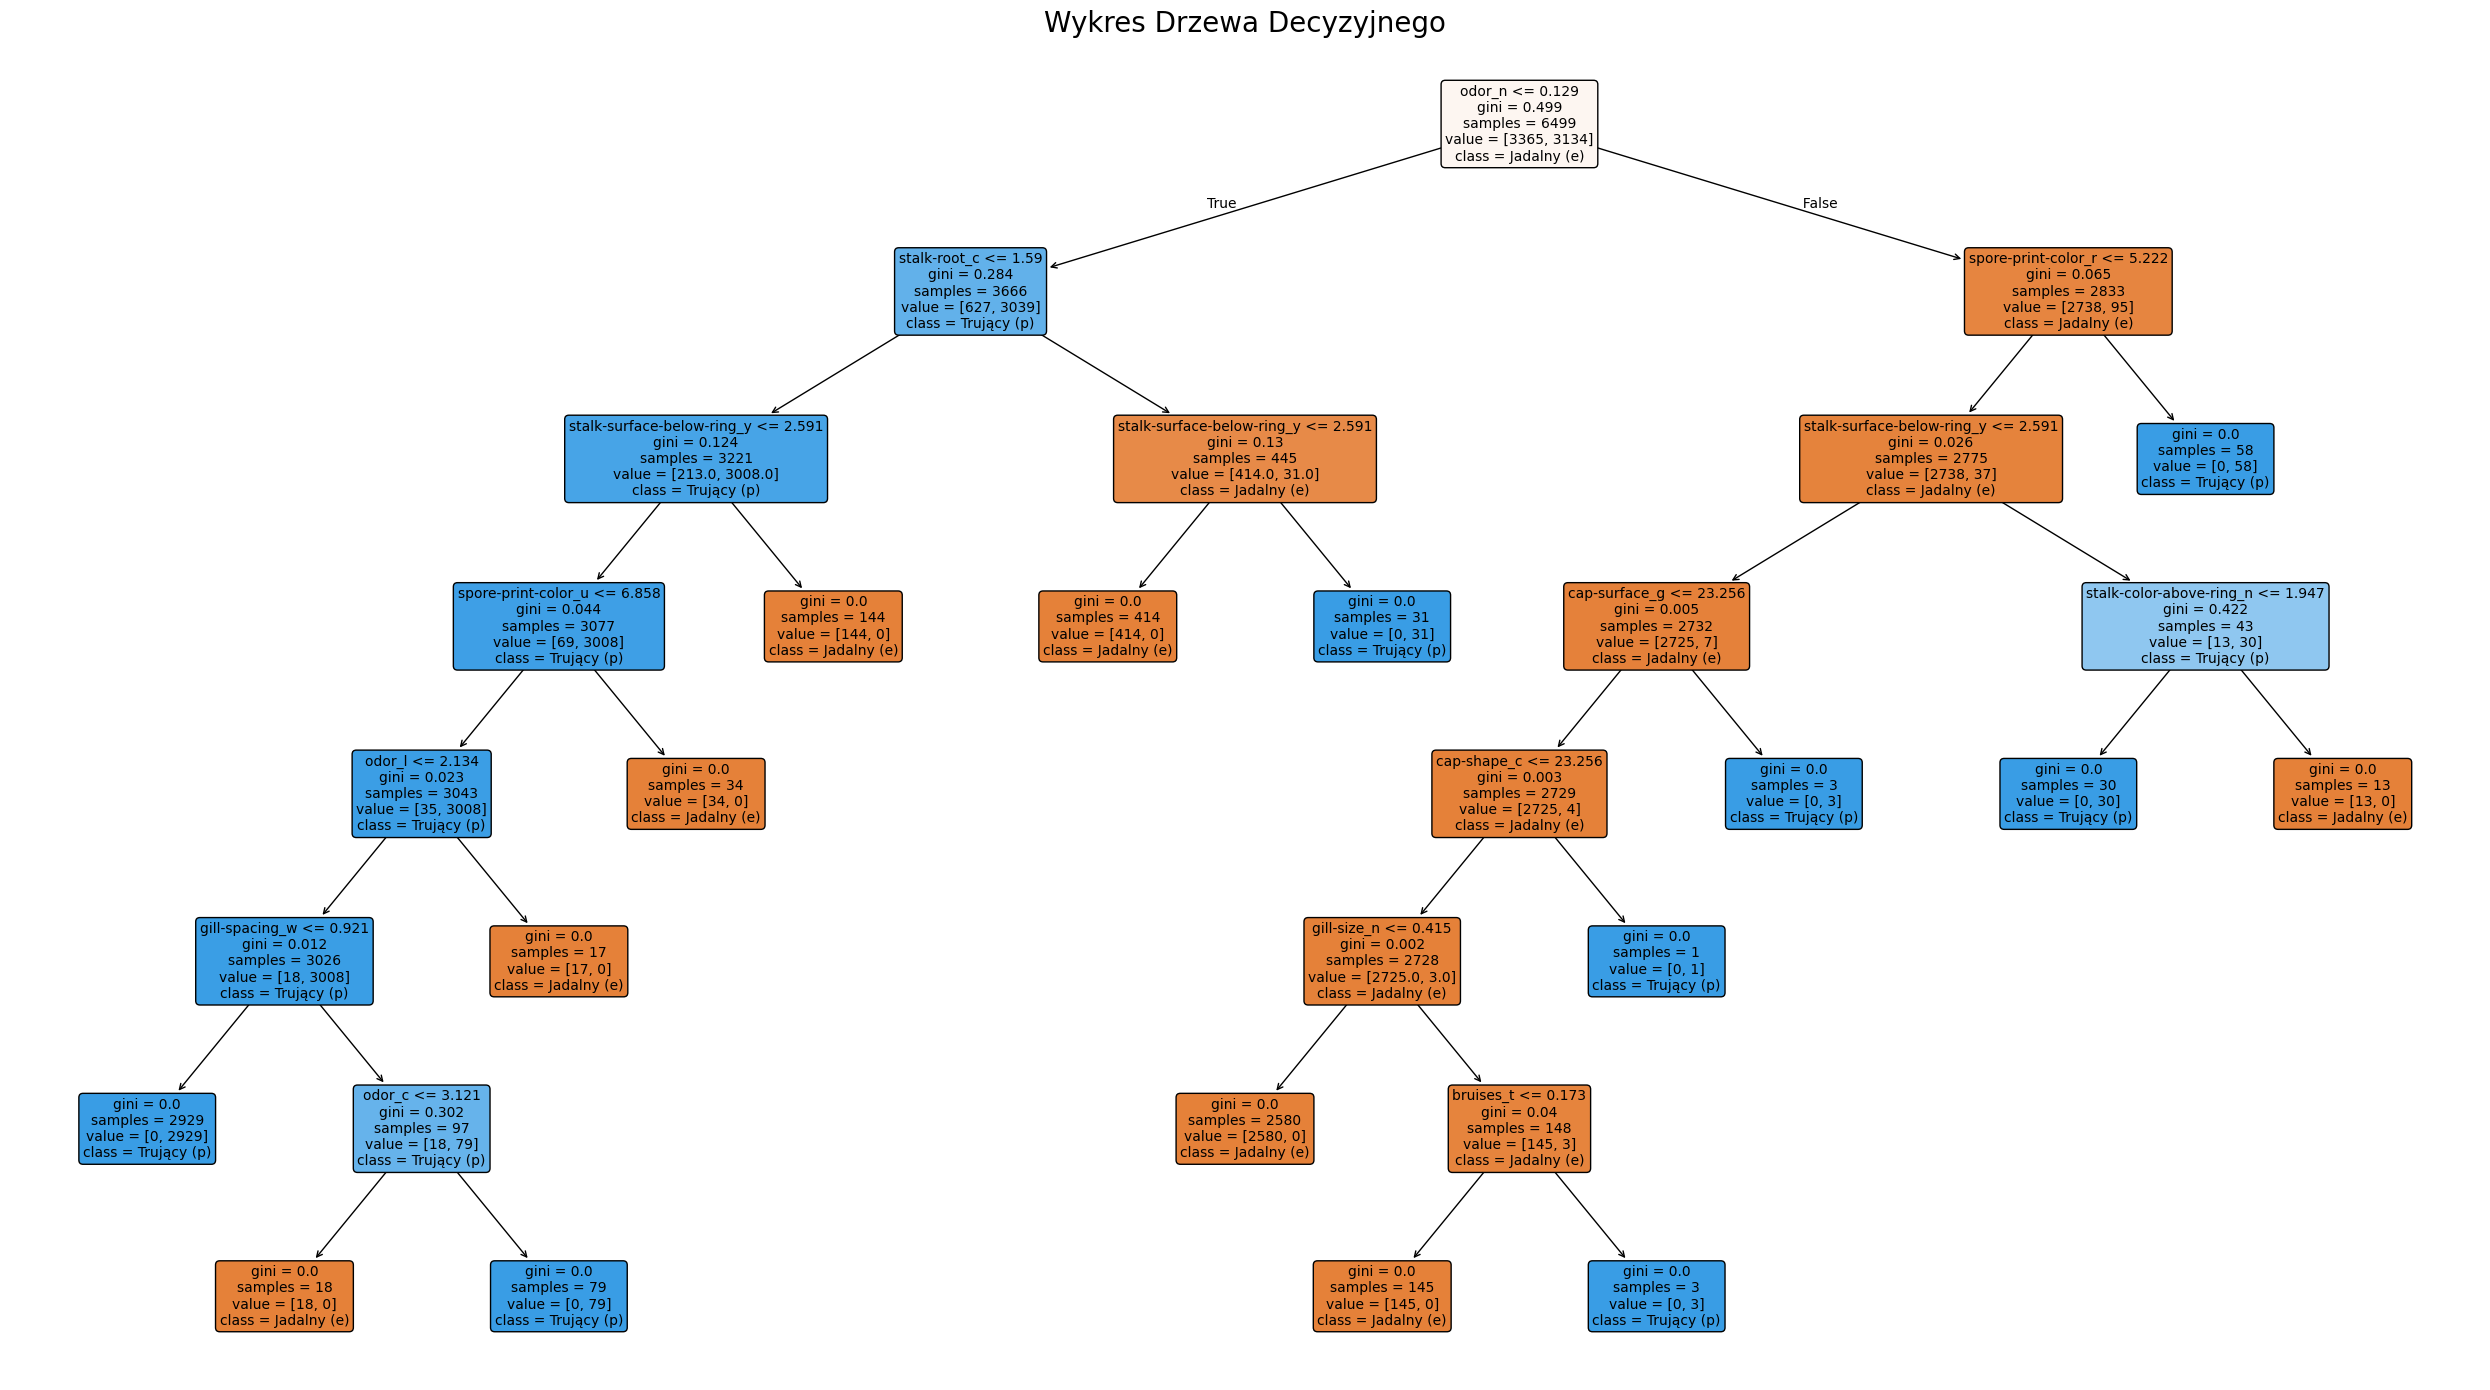

In [ ]:
plt.figure(figsize=(25, 14))

plot_tree(base_tree,
          feature_names=X_combined.columns,
          class_names=["Jadalny (e)", "Trujący (p)"],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Wykres Drzewa Decyzyjnego', fontsize=20)
plt.tight_layout()
plt.show()

# **4. Wnioski**

**Model Rekomendowany:** Pojedyncze Drzewo Decyzyjne

Okazuje się, że jest ono najszybsze i zwraca Recall na poziomie 100%. To znaczy, że idealnie odseparowywała grzyby trujące od grzybów zdrowych.

Do tego jest ono bardzo dobre interpretowalne dla człowieka więc zawsze można zobaczyć na jakiej podstawie algorytm podjął decyzję.

Zdecydowanie **nie powinniśmy wybierać modeli zespołowych** (Ensemble). Są one o wiele wolniejsze i zdarzają się im błędy.

Możemy tutaj wyróżnić Bagging dla drzew decyzyjnych z max_depth=3. Dalej teoretycznie ma on dobre statystyki ale ze względu na specyfikę powinniśmy się trzymać od niego z daleka. Był jeden przypadek FN, a więc jeden grzyb trujący został oceniony jako zdrowy. To o 1 za dużo w naszym przypadku